In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


# VGAE Generation on Artificial Graphs (Wrapper-Only)

This notebook uses only `VGAENetworkXGenerator` to fit on NetworkX graphs and generate same-type samples.

In [2]:
%config InlineBackend.figure_format = 'retina'

import random
import numpy as np

from abstractgraph import ArtificialGraphDatasetConstructor
from abstractgraph_generative import VGAEGraphGenerator
from abstractgraph.display import display_graphs

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        if target == 0:
            for u in graph.nodes():
                graph.nodes[u]['label'] += offset
        out_graphs.append(graph.copy())
    return out_graphs, targets


def select_pos_neg(sampled_graphs, sampled_targets, n_lines=3, n_graphs_per_line=12):
    import random
    k = n_graphs_per_line * n_lines
    pos_candidates = [g for g, t in zip(sampled_graphs, sampled_targets) if t == 1]
    neg_candidates = [g for g, t in zip(sampled_graphs, sampled_targets) if t != 1]
    pos_graphs = random.sample(pos_candidates, k=min(k, len(pos_candidates)))
    neg_graphs = random.sample(neg_candidates, k=min(k, len(neg_candidates)))
    return pos_graphs, neg_graphs

#graphs: 800
#positive: 400
#negative: 400


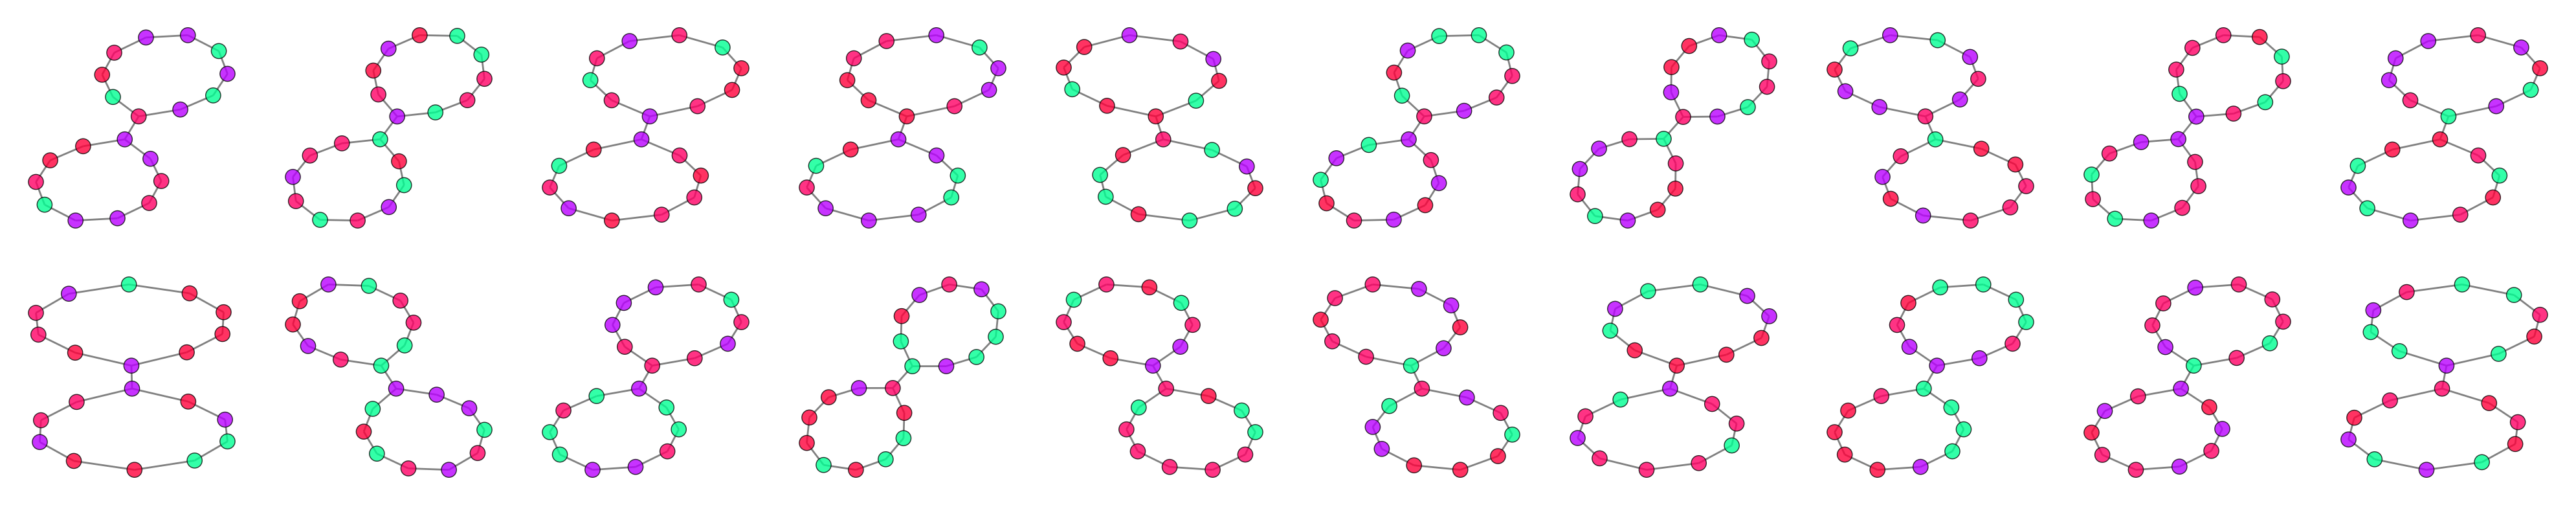

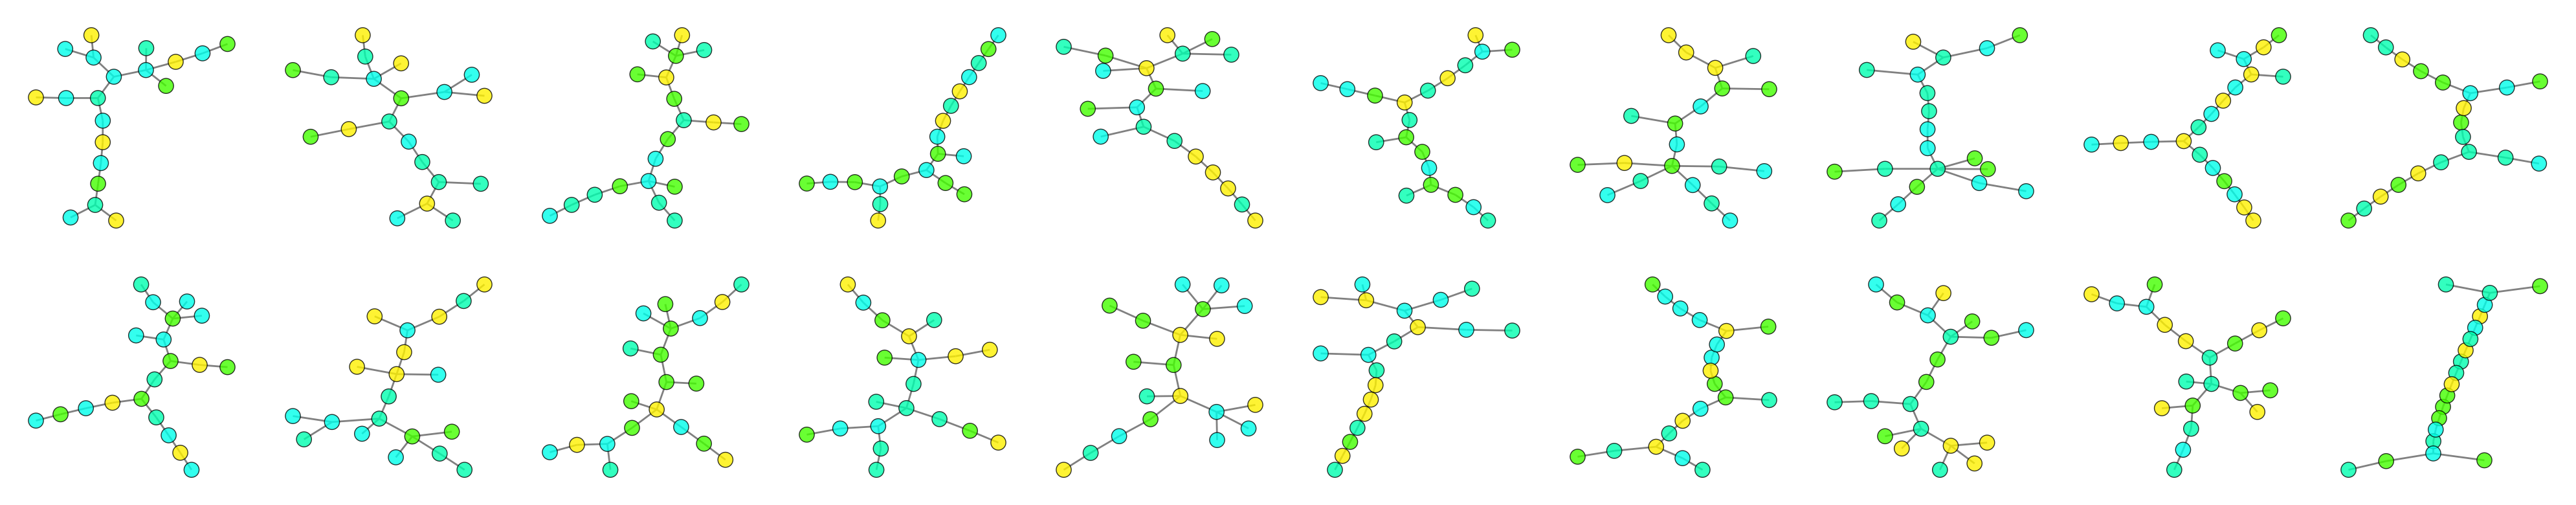

In [4]:
dataset_size = 800
alphabet_size = 4
size = 10
graph_types = ['path', 'tree', 'cycle', 'degree', 'regular', 'dense']

graphs, targets = ArtificialGraphDatasetConstructor(
    graph_generator_target_type_pos='cycle',
    graph_generator_context_type_pos='cycle',
    graph_generator_target_type_neg='tree',
    graph_generator_context_type_neg='tree',
    target_size_pos=size,
    context_size_pos=size,
    n_link_edges_pos=1,
    alphabet_size_pos=alphabet_size,
    target_size_neg=size,
    context_size_neg=size,
    n_link_edges_neg=1,
    alphabet_size_neg=alphabet_size,
).sample(dataset_size // 2)

graphs, targets = offset_neg_graphs(graphs, targets, offset=alphabet_size + 1)

print(f'#graphs: {len(graphs)}')
print(f'#positive: {sum(t == 1 for t in targets)}')
print(f'#negative: {sum(t != 1 for t in targets)}')


n_graphs_per_line = 10
pos_graphs, neg_graphs = select_pos_neg(graphs, targets, n_lines=2, n_graphs_per_line=n_graphs_per_line)

from abstractgraph.display import display_graphs
s=2
_ = display_graphs(pos_graphs, n_graphs_per_line=n_graphs_per_line, size=(s,s))
_ = display_graphs(neg_graphs, n_graphs_per_line=n_graphs_per_line, size=(s,s))

In [5]:
generator = VGAEGraphGenerator(
    random_state=SEED,
    verbose=True,
)
generator.fit(graphs, targets=targets)

[VGAE][type=1][split=0] epoch=001/500 beta=0.0100 train_obj=9.327215 patience=0/5 val_obj=7.052570 val_bce=12.848788 val_ap=0.268219
[VGAE][type=1][split=0] epoch=002/500 beta=0.0200 train_obj=3.995879 patience=0/5 val_obj=2.654157 val_bce=4.662868 val_ap=0.305812
[VGAE][type=1][split=0] epoch=003/500 beta=0.0300 train_obj=1.642059 patience=0/5 val_obj=1.272768 val_bce=1.982857 val_ap=0.292656
[VGAE][type=1][split=0] epoch=004/500 beta=0.0400 train_obj=1.039271 patience=0/5 val_obj=0.935844 val_bce=1.389184 val_ap=0.287391
[VGAE][type=1][split=0] epoch=005/500 beta=0.0500 train_obj=0.837547 patience=0/5 val_obj=0.795469 val_bce=1.157892 val_ap=0.314138
[VGAE][type=1][split=0] epoch=006/500 beta=0.0600 train_obj=0.730482 patience=0/5 val_obj=0.714740 val_bce=1.024162 val_ap=0.341355
[VGAE][type=1][split=0] epoch=007/500 beta=0.0700 train_obj=0.660654 patience=0/5 val_obj=0.653750 val_bce=0.921845 val_ap=0.368867
[VGAE][type=1][split=0] epoch=008/500 beta=0.0800 train_obj=0.630454 patien

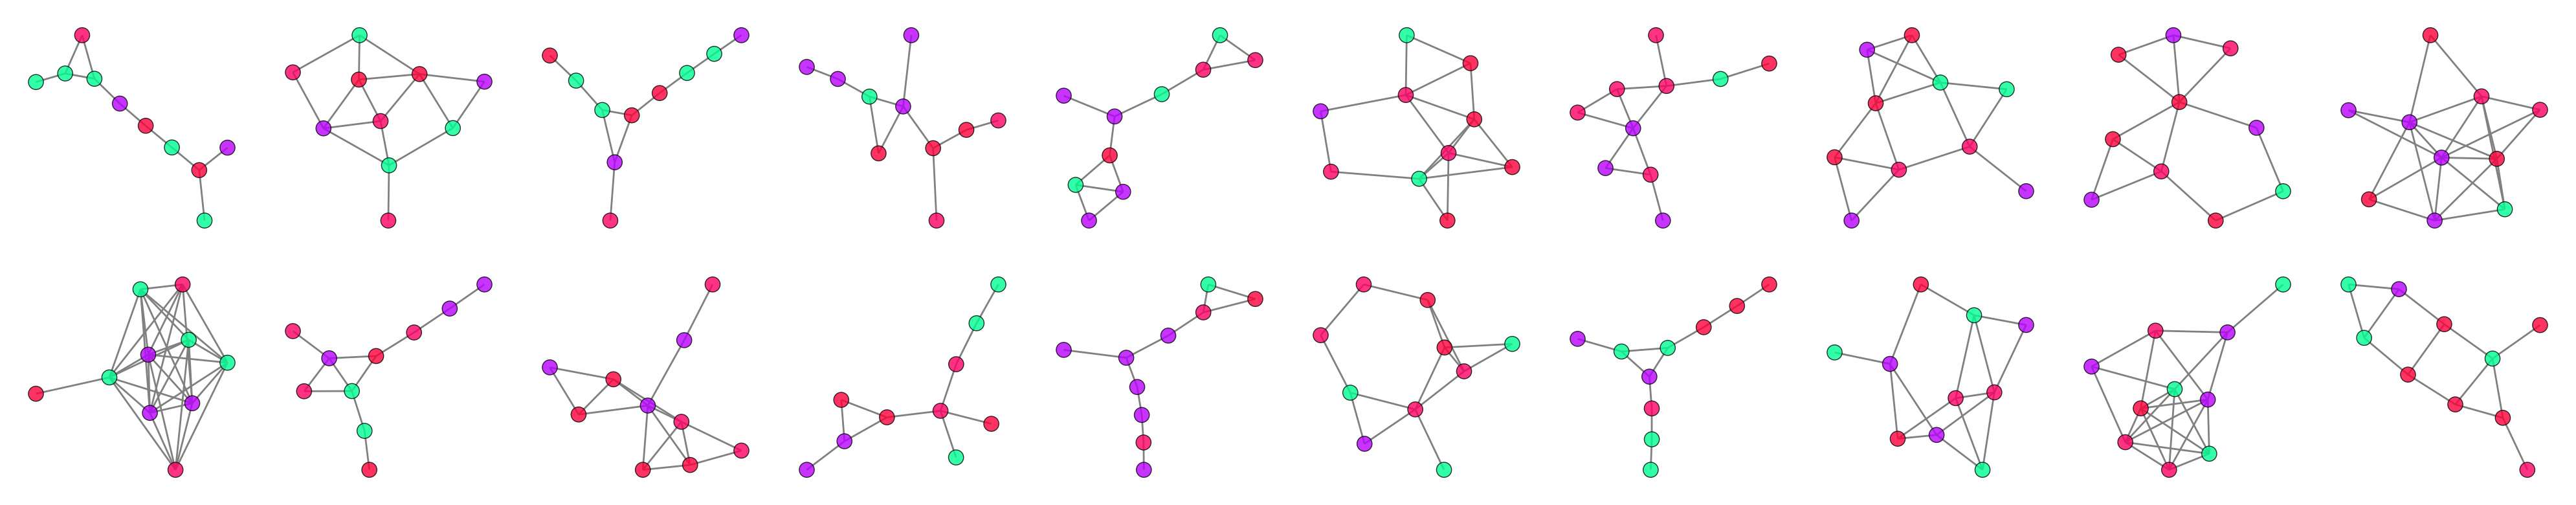

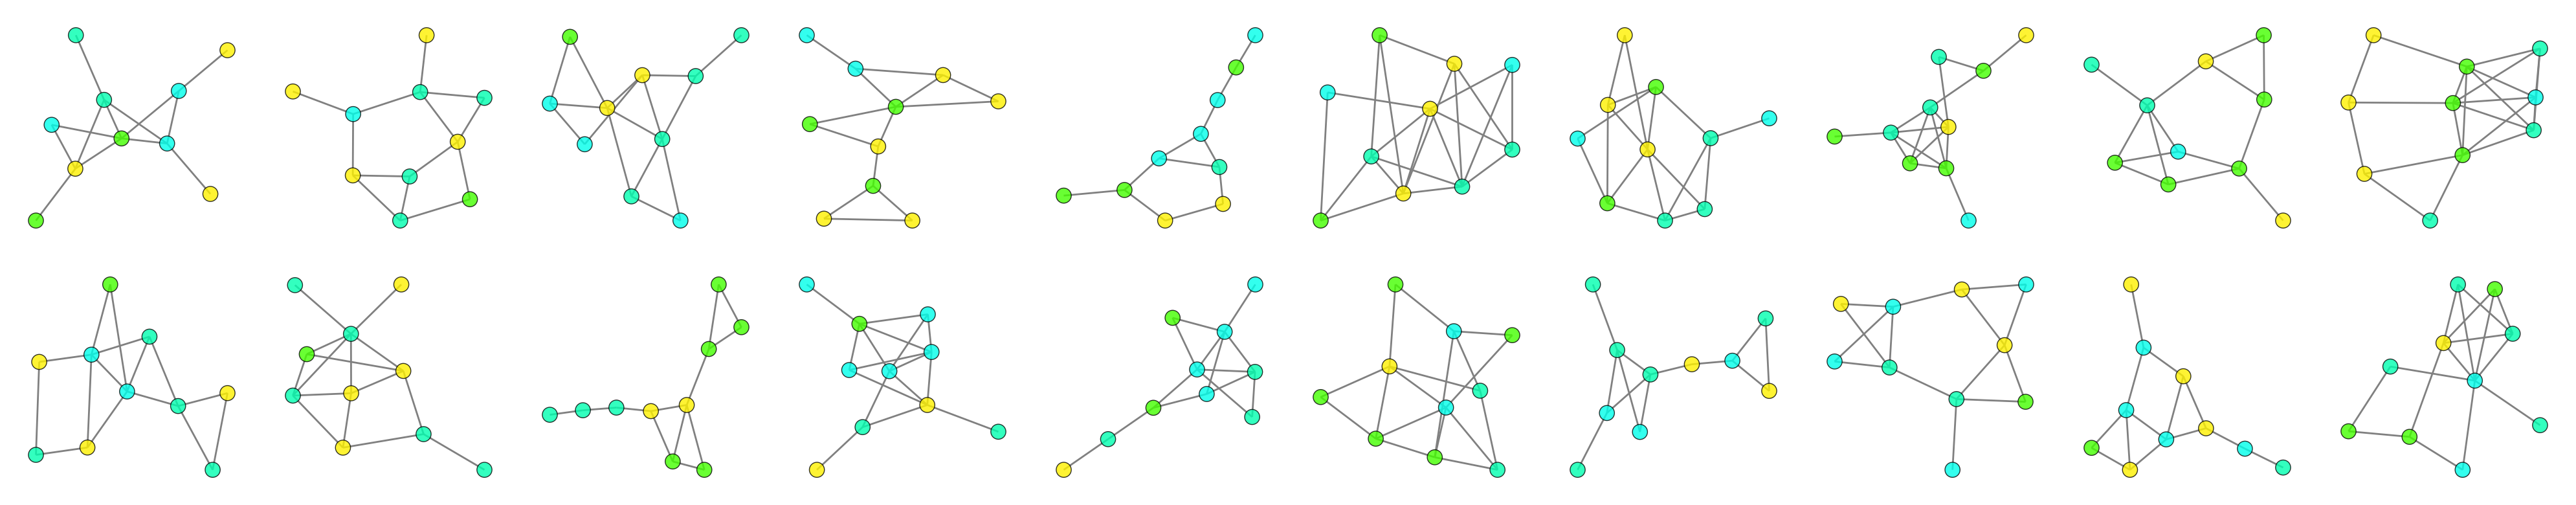

In [6]:
n_graphs_per_line = 10
num_graphs = 2 * n_graphs_per_line

pos_generated_graphs = generator.generate(
    num_graphs=num_graphs,
    graph_type=1,
    num_nodes=size,
    seed=SEED,
)
neg_generated_graphs = generator.generate(
    num_graphs=num_graphs,
    graph_type=0,
    num_nodes=size,
    seed=SEED + 1,
)
_ = display_graphs(pos_generated_graphs, n_graphs_per_line=n_graphs_per_line, size=(s,s))
_ = display_graphs(neg_generated_graphs, n_graphs_per_line=n_graphs_per_line, size=(s,s))